# Preprocessing pipeline

Stuff for preprocessing the data

___

## Data onboarding and preprocessing

### Load data

In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

dir_path = "training_data"

data = []
for label in range(10): 
    for file_path in [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and f"stroke_{label}" in f]: 
        data.append((label, pd.read_csv(file_path, header=None)))

### Project to 2D

In [2]:
from sklearn.decomposition import PCA

use_PCA = True
use_weights_PCA = True

data_projected = []

for label, df in data: 

    # Convert data to a matrix
    coordinates = df.to_numpy()
    
    if not use_PCA: # Just use x and y dimensions

        # --- DON'T USE PCA ---#

        # Rearrange the coordinates for image processing
        coordinates = coordinates[:, [1, 0, 2]]   
        data_projected.append((label, coordinates))  
    
    else:

        # --- USE PCA ---#

        # Apply weights (helps retain up and down directions in the data)
        if use_weights_PCA: 
            w = np.array([1.0, 2.0, 0.5])
            coordinates = coordinates * w

        # Fit PCA
        coordinates = PCA(n_components=3).fit_transform(coordinates) 

        # Apply inverse weights
        if use_weights_PCA: 
            coordinates /= (-np.array(np.sort(-w)))

        data_projected.append((label, coordinates))  

### Convert data to images

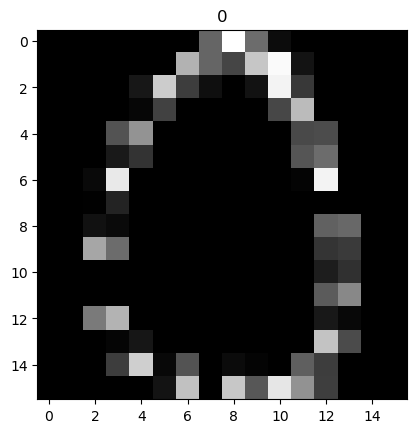

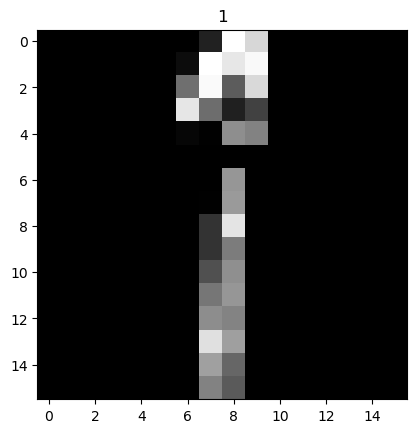

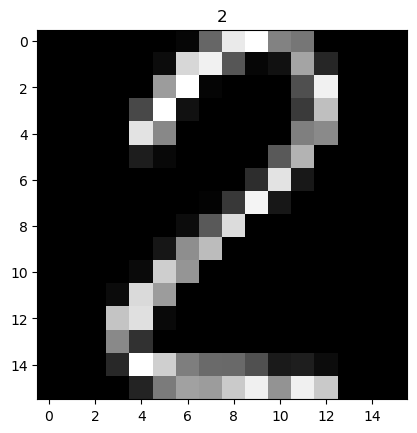

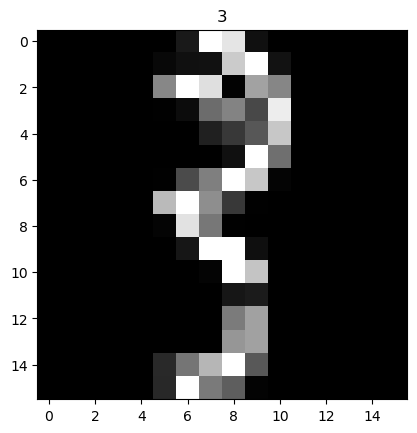

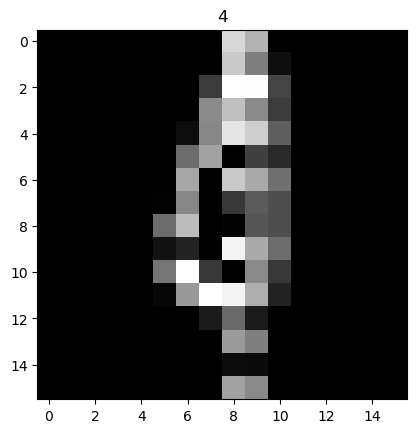

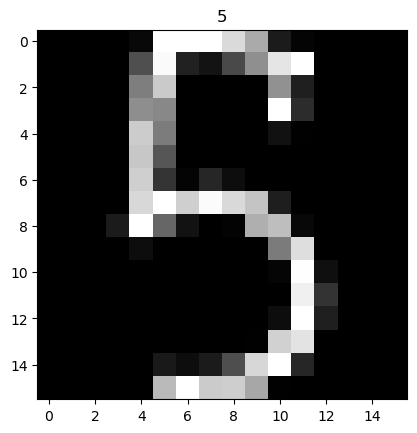

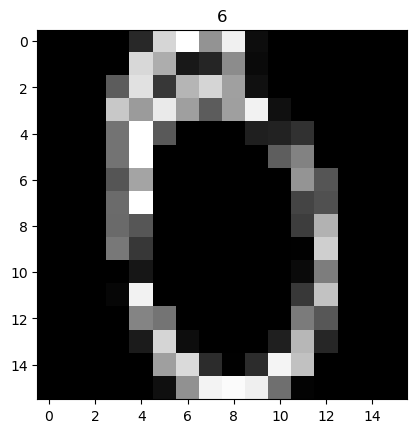

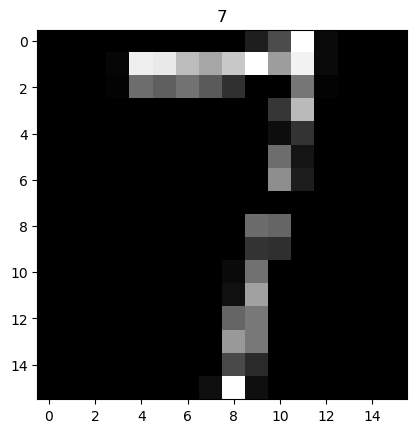

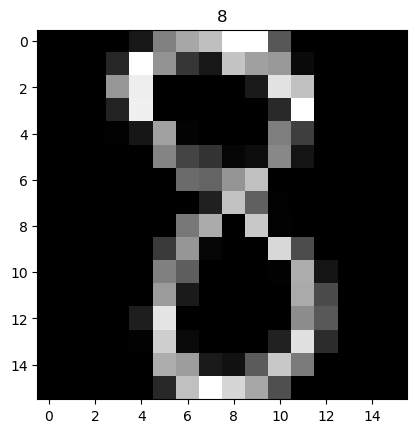

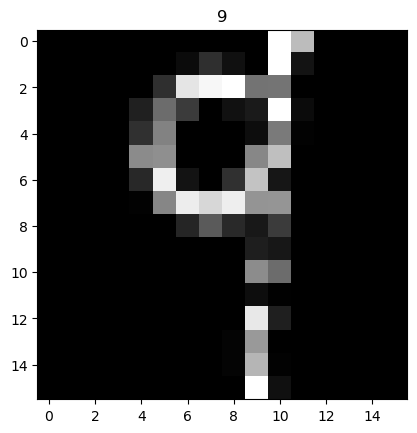

In [3]:
N = 16 # This is image width/height (square "images")
data_images = []

for label, coordinates in data_projected: 

    # Scale the coordinates
    coordinates = coordinates - (np.min(coordinates, axis=0) + np.max(coordinates, axis=0)) / 2 # Center the sample to 0
    coordinates = coordinates / np.max(np.abs(coordinates)) # Scale to range [-1, 1]
    coordinates = coordinates * ((N-1) / 2) + ((N-1) / 2) # Scale to range [0, N-1]

    # Extract coordinates
    x, y, z = coordinates[:, 1], coordinates[:, 0], 1
    x_floor, x_ceil = np.floor(x).astype(int), np.ceil(x).astype(int)
    y_floor, y_ceil = np.floor(y).astype(int), np.ceil(y).astype(int)

    # Convert x, y data to pixels in an image
    image = np.zeros((N, N))
    image[y_floor, x_floor] += z * ((1 - y % 1) * (1 - x % 1))
    image[y_ceil, x_ceil] += z * ((y % 1) * (x % 1))
    image[y_floor, x_ceil] += z * ((x % 1) * (1 - y % 1))
    image[y_ceil, x_floor] += z * ((1 - x % 1) * (y % 1))

    # "Amplify" the signal 
    # image = 2 * image # Amplify

    # Clip the pixel values to range [0, 1]
    image = np.clip(image, 0, 1)
    
    # Flip the image (so that it is not upside down) and add it to list
    image = np.flip(image, 0)

    # Add image to list
    data_images.append((label, image))

# Show some images
for label, image in data_images[::100]: 
    plt.figure()
    plt.imshow(image, cmap='Grays_r')
    plt.title(label)


### Stack images and labels to arrays

In [4]:
X = np.stack([image for _, image in data_images])
y = np.array([label for label, _ in data_images])